# Persona 2 — Indice y Spread

Indice leave-one-out, estimacion de beta, spreads y pruebas de estacionariedad.

## 1. Descarga de datos con cache en CSV

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path

tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']
start = '2008-01-01'
end = '2025-01-01'

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'precios_cierre.csv'

if csv_path.exists():
    print('Leyendo CSV cacheado...')
    data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    print('Descargando datos desde yfinance...')
    raw = yf.download(tickers, start=start, end=end, auto_adjust=False)
    data = raw['Close']
    data.to_csv(csv_path)
    print(f'Datos guardados en {csv_path}')

print(f'Shape (crudo): {data.shape}')

# truncamos al rango comun donde todos los tickers tienen datos
data = data.dropna()
print(f'Shape (rango comun): {data.shape}')
print(f'Rango de fechas: {data.index[0].date()} a {data.index[-1].date()}')
data.head()

Leyendo CSV cacheado...
Shape (crudo): (4279, 8)
Shape (rango comun): (1739, 8)
Rango de fechas: 2018-02-02 a 2024-12-31


,BMA,CEPU,GGAL,LOMA,PAM,SUPV,TGS,YPF
Date,,,,,,,,
2018-02-02,100.830002,17.700001,63.650002,22.990000,64.849998,30.389999,21.770000,23.190001
2018-02-05,96.690002,17.500000,61.320000,21.770000,62.259998,29.100000,21.219999,22.549999
2018-02-06,101.220001,17.410000,64.389999,22.500000,65.489998,30.170000,22.900000,22.950001
2018-02-07,99.330002,17.110001,63.029999,21.889999,63.799999,29.930000,22.500000,22.070000
2018-02-08,95.459999,16.400000,60.290001,21.160000,61.139999,28.260000,20.920000,21.430000


## 2. Retornos diarios

Calculamos retornos diarios para cada accion:  $r_t = \frac{P_t}{P_{t-1}} - 1$

In [2]:
returns = data.pct_change().dropna()
print(f'Retornos - Shape: {returns.shape}')
print(f'Rango de fechas: {returns.index[0].date()} a {returns.index[-1].date()}')
returns.head()

Retornos - Shape: (1738, 8)
Rango de fechas: 2018-02-05 a 2024-12-31


,BMA,CEPU,GGAL,LOMA,PAM,SUPV,TGS,YPF
Date,,,,,,,,
2018-02-05,-0.041059,-0.011299,-0.036606,-0.053067,-0.039938,-0.042448,-0.025264,-0.027598
2018-02-06,0.046851,-0.005143,0.050065,0.033532,0.051879,0.036770,0.079171,0.017738
2018-02-07,-0.018672,-0.017231,-0.021121,-0.027111,-0.025805,-0.007955,-0.017467,-0.038344
2018-02-08,-0.038961,-0.041496,-0.043471,-0.033349,-0.041693,-0.055797,-0.070222,-0.028999
2018-02-09,-0.006495,0.057927,-0.022226,0.017486,-0.035002,0.015924,-0.023901,-0.014466


## 3. Indices sinteticos leave-one-out

Para cada accion construimos un indice con el promedio de retornos de **las demas** acciones y lo acumulamos:

$$I_{-a, t} = I_{-a, t-1} \cdot (1 + \bar{r}_{-a, t})$$

con $I_{-a, 0} = 1$

In [3]:
indices_loo = {}

for ticker in tickers:
    otros = [t for t in tickers if t != ticker]
    ret_promedio = returns[otros].mean(axis=1)
    indice = (1 + ret_promedio).cumprod()
    indice.iloc[0] = 1.0
    indices_loo[ticker] = indice

indices_loo = pd.DataFrame(indices_loo, index=returns.index)
print(f'Indices LOO - Shape: {indices_loo.shape}')
indices_loo.head()

Indices LOO - Shape: (1738, 8)


,YPF,GGAL,BMA,SUPV,LOMA,CEPU,PAM,TGS
Date,,,,,,,,
2018-02-05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2018-02-06,1.004712,1.001594,1.002697,1.004295,1.006319,1.005431,1.001837,0.995905
2018-02-07,0.985284,0.979761,0.980490,0.980514,0.985244,0.982956,0.980670,0.973676
2018-02-08,0.939540,0.936299,0.936364,0.938746,0.940115,0.939075,0.936918,0.934205
2018-02-09,0.940038,0.937834,0.935794,0.935168,0.936322,0.929862,0.940164,0.935960


### Verificacion: accion vs su indice leave-one-out

Graficamos cada accion normalizada (base 100) contra su indice LOO.

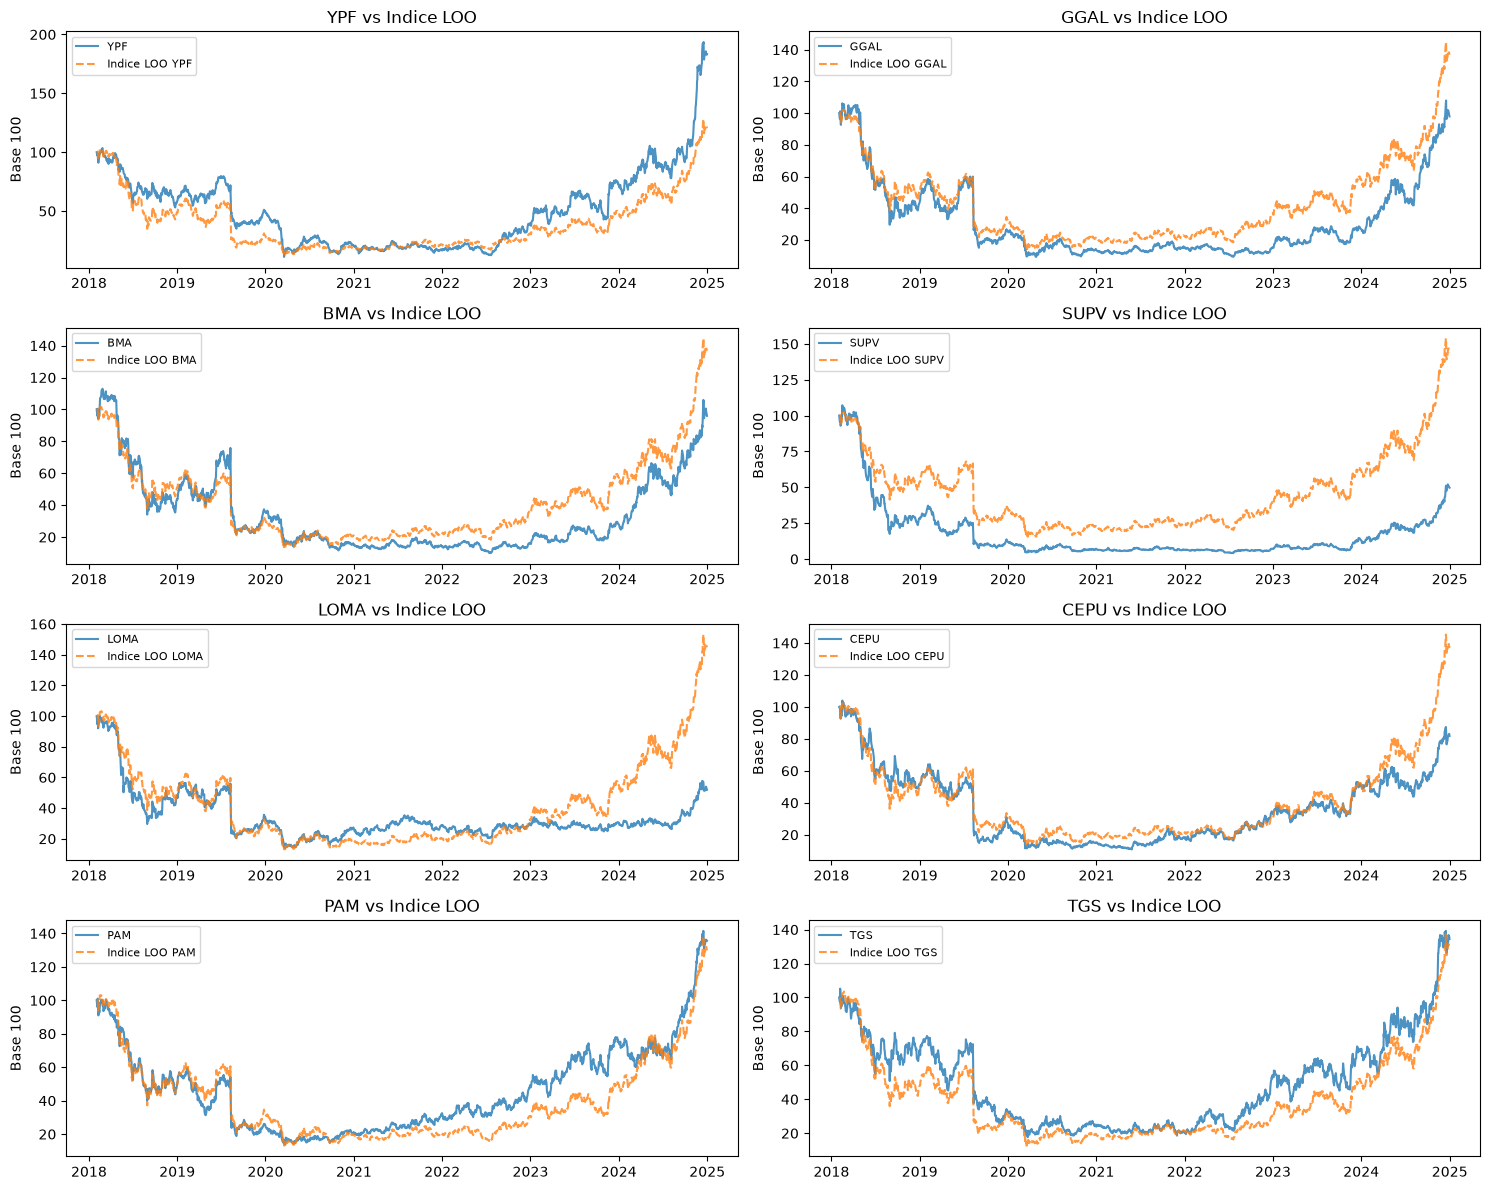

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    precio_norm = data[ticker] / data[ticker].iloc[0] * 100
    indice_norm = indices_loo[ticker] / indices_loo[ticker].iloc[0] * 100
    ax.plot(precio_norm.index, precio_norm, label=ticker, alpha=0.8)
    ax.plot(indice_norm.index, indice_norm, label=f'Indice LOO {ticker}', alpha=0.8, linestyle='--')
    ax.set_title(f'{ticker} vs Indice LOO')
    ax.legend(fontsize=8)
    ax.set_ylabel('Base 100')

plt.tight_layout()
plt.show()

### Comparacion: todos los indices LOO juntos

Como cada indice excluye solo 1 de 8 acciones, deberian ser practicamente identicos.

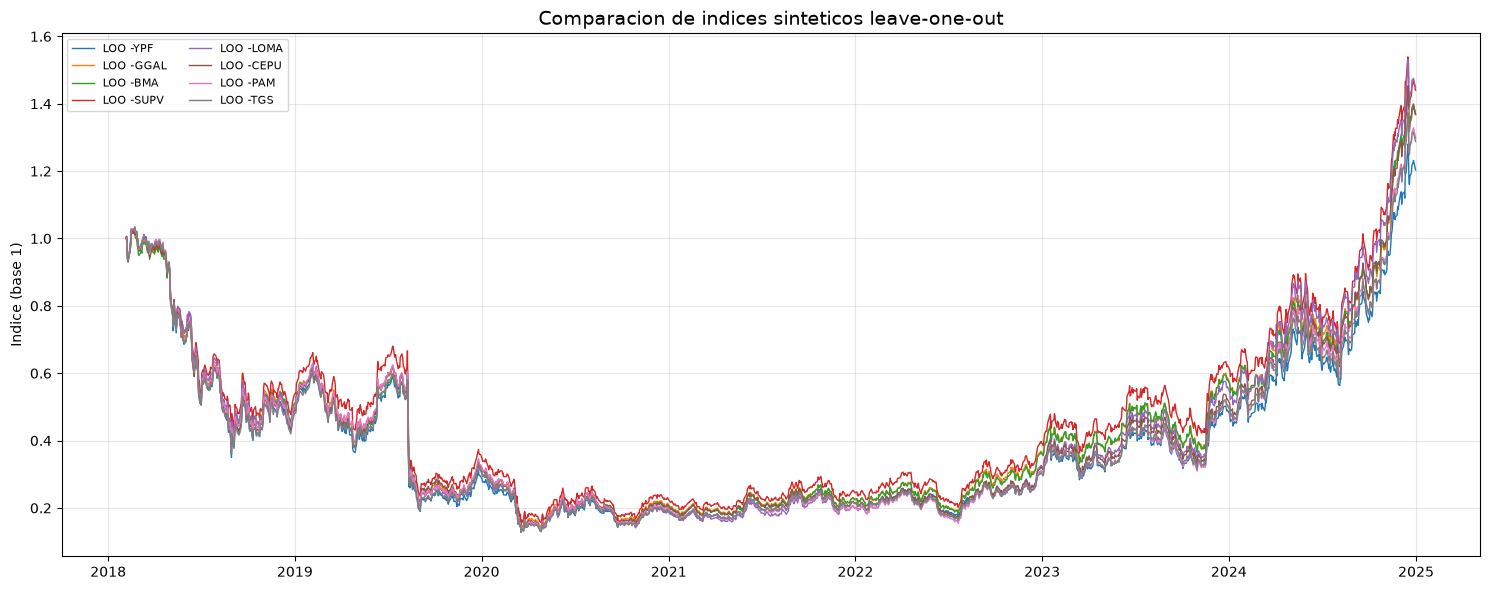

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

for ticker in tickers:
    ax.plot(indices_loo.index, indices_loo[ticker], label=f'LOO -{ticker}', linewidth=1)

ax.set_title('Comparacion de indices sinteticos leave-one-out', fontsize=14)
ax.set_ylabel('Indice (base 1)')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()